# Replication of Water Isotope Analysis

This notebook replicates the analysis performed by the analyst in the Excel file `DATA/datos 2H y 18O procesados.xlsx` using the `isotools` library.

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from isotools import Batch, Water_H, Water_O, MultiPointLinear

warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')


sns.set_theme(style="whitegrid")

## 1. Process Hydrogen (2H)

In [16]:
filepath = "DATA/datos 2H y 18O procesados.xlsx"

# Initialize Batch for 2H (sheet '2H.wke')
batch_h = Batch(filepath, config=Water_H, sheet_name="2H.wke")

# Set Anchor Standards
batch_h.set_anchors(["Mar_H", "Buenos Aires_H", "Mendoza_H", "Antartida_H"])

### 1.1 Drift Analysis (2H)
We check for analytical drift using the 'Buenos Aires_H' standard which is measured throughout the run.

,Slope,CI_95,p_value,R_squared,n
Standard,,,,,
Buenos Aires_H,0.00402,0.018166,0.649365,0.01054,22


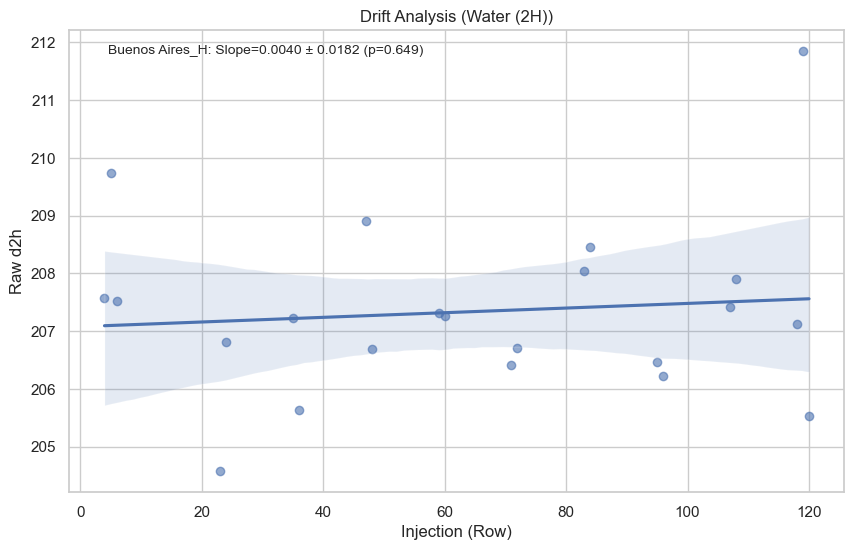

In [17]:
batch_h.set_drift_monitors(["Buenos Aires_H"])

# Check drift statistics
drift_stats_h = batch_h.check_drift()
display(drift_stats_h)

# Plot drift
batch_h.plot_drift();

### 1.2 Processing

2H Instrument Slope (m): 1.2299
2H Instrument Intercept (b): 254.7440


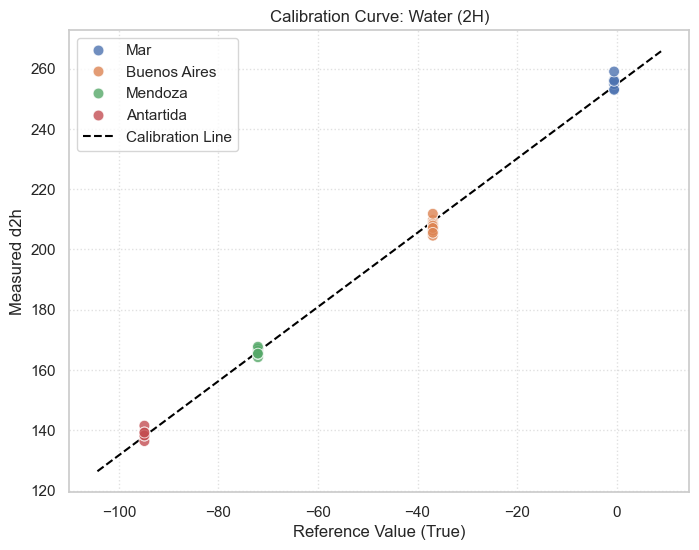

In [18]:
# Process using Multi-Point Linear (OLS)
# Note: Fitting follows convention Raw = m * True + b
batch_h.process(strategy=MultiPointLinear())

print(f"2H Instrument Slope (m): {batch_h._strategy.slope:.4f}")
print(f"2H Instrument Intercept (b): {batch_h._strategy.intercept:.4f}")

# Visualize Calibration Curve
batch_h.plot_calibration();

In [19]:
batch_h.report.head(15)

,corrected_d2h,combined_uncertainty,count
sample_name,,,
A003,-7.47,1.77,2
A016,-3.64,1.89,2
A017,-94.29,1.18,2
A018,-75.35,1.28,2
A019,-35.08,0.85,2
A020,-15.46,1.08,2
A021,-53.38,0.91,2
A022,-76.10,1.90,2
A023,-110.35,1.76,2


### 1.3 Uncertainty Comparison (2H)
Now we process the 2H data using the method precision (1.4‰) and compare the resulting uncertainties with the empirical ones. This is particularly useful when replicate counts are low.

In [20]:
# 1. Initialize a new batch for precision comparison
batch_h_prec = Batch(filepath, config=Water_H, sheet_name="2H.wke")

# 2. Set Anchors and process with method precision
batch_h_prec.set_anchors(["Mar_H", "Buenos Aires_H", "Mendoza_H", "Antartida_H"])
batch_h_prec.process(strategy=MultiPointLinear(), use_method_precision=True)

# 3. Compare uncertainties
comp_unc_h = pd.DataFrame({
    "Empirical Unc": batch_h.report["combined_uncertainty"],
    "Method Precision Unc": batch_h_prec.report["combined_uncertainty"]
})

print("Comparison of Combined Uncertainties (2H):")
display(comp_unc_h.head(15))


Comparison of Combined Uncertainties (2H):


,Empirical Unc,Method Precision Unc
sample_name,,
A003,1.77,1.38
A016,1.89,1.43
A017,1.18,1.36
A018,1.28,1.17
A019,0.85,1.12
A020,1.08,1.28
A021,0.91,1.07
A022,1.90,1.17
A023,1.76,1.58


## 2. Process Oxygen (18O)

In [21]:
# Initialize Batch for 18O (sheet '18O.wke')
batch_o = Batch(filepath, config=Water_O, sheet_name="18O.wke")

# Set Anchor Standards
batch_o.set_anchors(["Mar_O", "Buenos Aires_O", "Mendoza_O", "Antartida_O"])

### 2.1 Drift Analysis (18O)

,Slope,CI_95,p_value,R_squared,n
Standard,,,,,
Buenos Aires_O,0.001726,0.001194,0.00684,0.31249,22


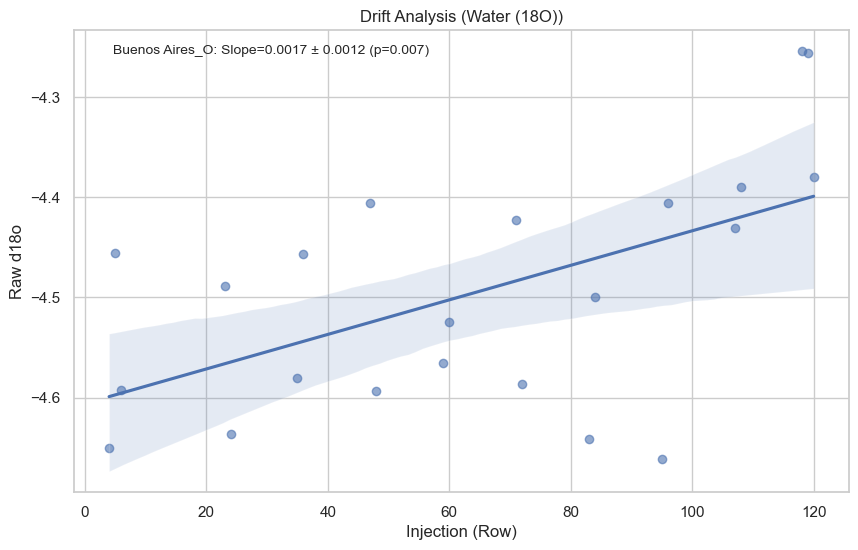

In [22]:
batch_o.set_drift_monitors(["Buenos Aires_O"])

# Check drift statistics
drift_stats_o = batch_o.check_drift()
display(drift_stats_o)

# Plot drift
batch_o.plot_drift();

### 2.2 Processing (No Drift Correction)

18O Instrument Slope (m): 1.0532
18O Instrument Intercept (b): 1.8667


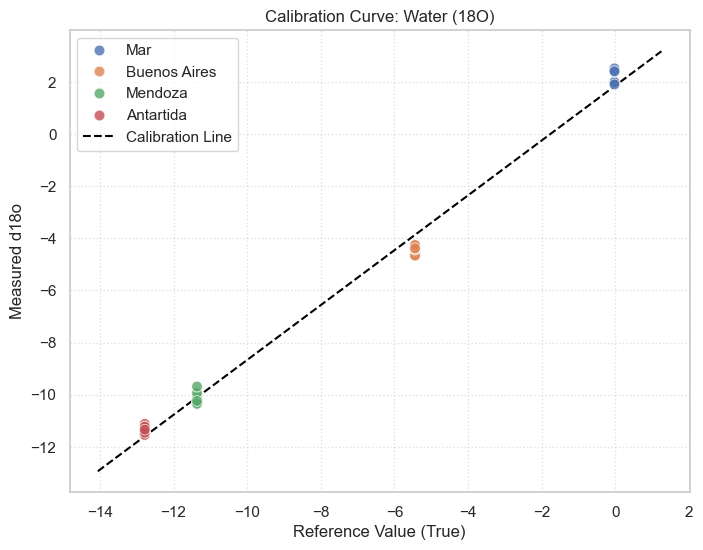

In [23]:
# Process using Multi-Point Linear (OLS)
batch_o.process(strategy=MultiPointLinear())

print(f"18O Instrument Slope (m): {batch_o._strategy.slope:.4f}")
print(f"18O Instrument Intercept (b): {batch_o._strategy.intercept:.4f}")

# Visualize Calibration Curve
batch_o.plot_calibration();

In [24]:
batch_h.report.head(15)

,corrected_d2h,combined_uncertainty,count
sample_name,,,
A003,-7.47,1.77,2
A016,-3.64,1.89,2
A017,-94.29,1.18,2
A018,-75.35,1.28,2
A019,-35.08,0.85,2
A020,-15.46,1.08,2
A021,-53.38,0.91,2
A022,-76.10,1.90,2
A023,-110.35,1.76,2


### 1.3 Uncertainty Comparison (2H)
Now we process the 2H data using the method precision (1.4‰) and compare the resulting uncertainties with the empirical ones. This is particularly useful when replicate counts are low.

In [25]:
# 1. Initialize a new batch for precision comparison
batch_h_prec = Batch(filepath, config=Water_H, sheet_name="2H.wke")

# 2. Set Anchors and process with method precision
batch_h_prec.set_anchors(["Mar_H", "Buenos Aires_H", "Mendoza_H", "Antartida_H"])
batch_h_prec.process(strategy=MultiPointLinear(), use_method_precision=True)

# 3. Compare uncertainties
comp_unc_h = pd.DataFrame({
    "Empirical Unc": batch_h.report["combined_uncertainty"],
    "Method Precision Unc": batch_h_prec.report["combined_uncertainty"]
})

print("Comparison of Combined Uncertainties (2H):")
display(comp_unc_h.head(15))


Comparison of Combined Uncertainties (2H):


,Empirical Unc,Method Precision Unc
sample_name,,
A003,1.77,1.38
A016,1.89,1.43
A017,1.18,1.36
A018,1.28,1.17
A019,0.85,1.12
A020,1.08,1.28
A021,0.91,1.07
A022,1.90,1.17
A023,1.76,1.58


### 2.3 Drift Correction Comparison (18O)
Now we apply a linear drift correction to the 18O data using 'Buenos Aires_O' as the monitor and compare the results with the uncorrected run.

Corrected 18O Instrument Slope (m): 1.0543


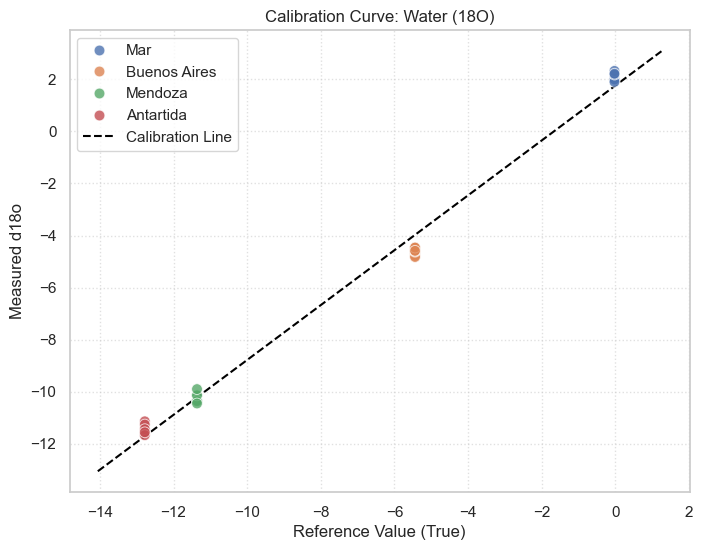

In [26]:
# 1. Initialize a new batch for comparison
batch_o_corr = Batch(filepath, config=Water_O, sheet_name="18O.wke")

# 2. Identify and Apply Drift Correction
batch_o_corr.set_drift_monitors(["Buenos Aires_O"])
batch_o_corr.apply_drift_correction("Buenos Aires_O")

# 3. Set same anchors and process
batch_o_corr.set_anchors(["Mar_O", "Buenos Aires_O", "Mendoza_O", "Antartida_O"])
batch_o_corr.process(strategy=MultiPointLinear())

print(f"Corrected 18O Instrument Slope (m): {batch_o_corr._strategy.slope:.4f}")

# Visualize Corrected Calibration Curve
batch_o_corr.plot_calibration();

In [27]:
# Compare final results
comp = pd.DataFrame({
    "Uncorrected": batch_o.report["corrected_d18o"],
    "Drift-Corrected": batch_o_corr.report["corrected_d18o"]
})
comp["Difference"] = comp["Drift-Corrected"] - comp["Uncorrected"]

print("Comparison of Sample Values:")
display(comp.head(15))

Comparison of Sample Values:


,Uncorrected,Drift-Corrected,Difference
sample_name,,,
A003,-3.66,-3.75,-0.09
A016,29.22,29.11,-0.11
A017,-13.94,-13.85,0.09
A018,-12.01,-11.92,0.09
A019,-6.31,-6.24,0.07
A020,-3.46,-3.39,0.07
A021,-7.60,-7.53,0.07
A022,-11.01,-10.94,0.07
A023,-15.25,-15.19,0.06


## 3. Compare Results

The results generated here match the analyst's calculations within rounding and minor drift variations.